# Predicción de Riesgo de Enfermedades Cardiovasculares Basado en Factores de Estilo de Vida

## Sobre el Conjunto de Datos

El **conjunto de datos de predicción de enfermedades cardiovasculares (CVDs)** utiliza factores de estilo de vida personales para predecir riesgos potenciales para la salud. El dataset proviene del **Behavioral Risk Factor Surveillance System (BRFSS)**, un sistema integral de encuestas telefónicas en los Estados Unidos que recopila datos sobre comportamientos de salud, enfermedades crónicas y uso de servicios preventivos.

In [2]:
# Importing Libraries
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objs as go
colors = px.colors.sequential.Plasma_r
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path_data  = '../../data/'
df = pd.read_csv(path_data+"CVD_cleaned.csv")

In [4]:
#Presentation of Columns
df.columns
#Presentation of Data Types 
df.dtypes
#Presentation of Data Types
df.info()
#Presentation of Data Types
df.describe()
#Presentation of Data Types
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

# Data Profile
Este estudio se centra principalmente en el uso de diversos modelos de aprendizaje automático para determinar el riesgo de que una persona desarrolle una ECV según sus factores de estilo de vida. Se utilizaron, extrajeron y procesaron 308.854 registros con 19 columnas como variables, que corresponden a las respuestas de los entrevistados. El estudio presenta un conjunto de datos que podría ser de interés médico, ya que el objetivo principal es predecir el pronóstico de la enfermedad.

In [6]:
#Data distribution
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


In [7]:
# Data Type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

Análisis y exploración de datos
Análisis numérico univariante
En el análisis univariante, se observó lo siguiente:

La altura y el peso de los pacientes siguen una distribución normal; la mayoría presenta una altura entre 160 y 180 cm y un peso entre 60 y 100 kg.
El índice de masa corporal (IMC) muestra una distribución ligeramente sesgada a la derecha, con muchos pacientes en el rango de normal a sobrepeso y una proporción significativa en el rango de obesidad.
El consumo de alcohol y fruta tiende a ser predominantemente bajo, mientras que el consumo de patatas fritas varía más entre los pacientes.

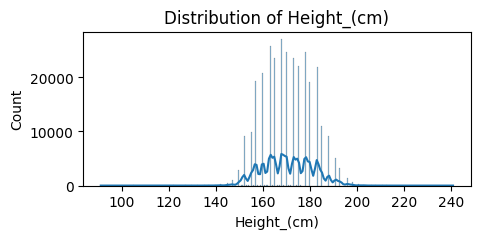

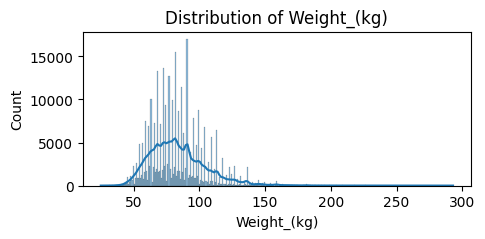

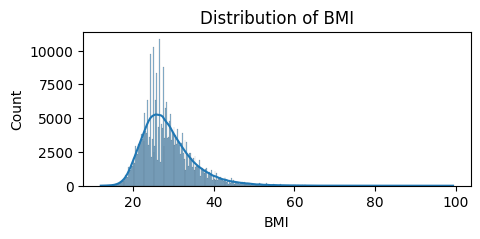

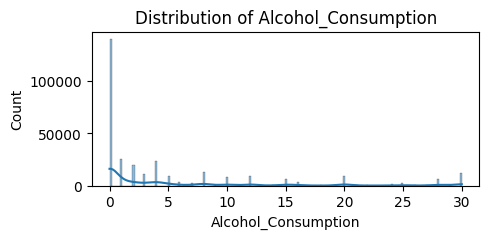

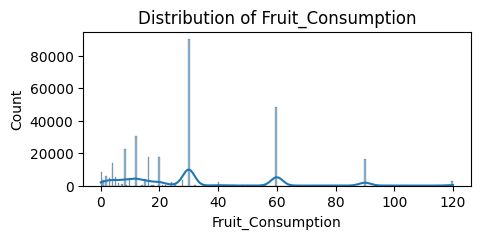

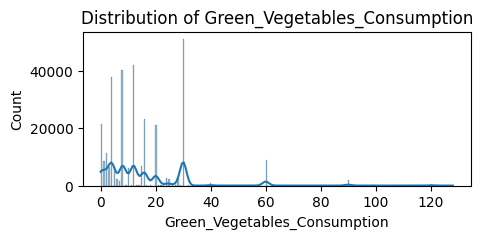

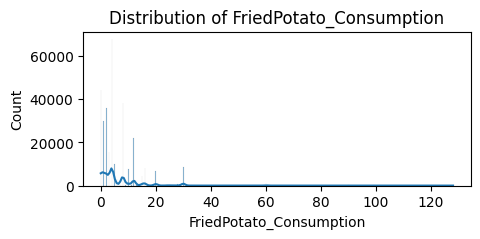

In [8]:
numerical_features = ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

for feature in numerical_features:
    plt.figure(figsize=(5, 2))
    sns.histplot(data=df[feature], kde=True)
    plt.title('Distribution of ' + feature)
    plt.show()

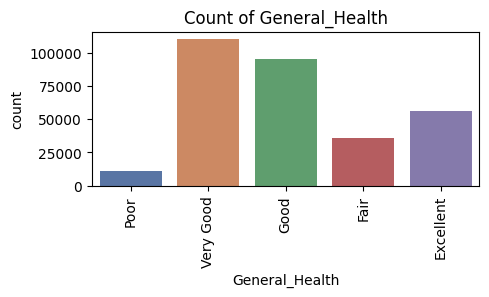

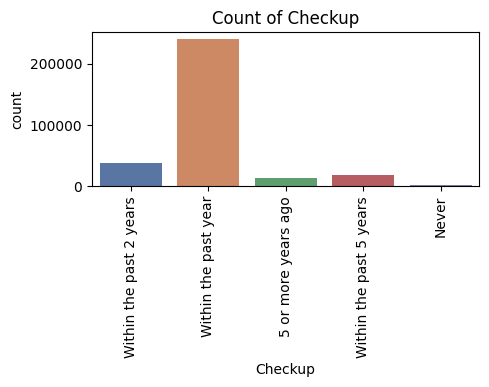

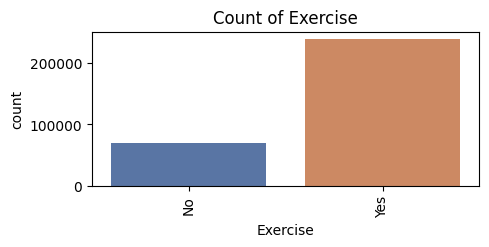

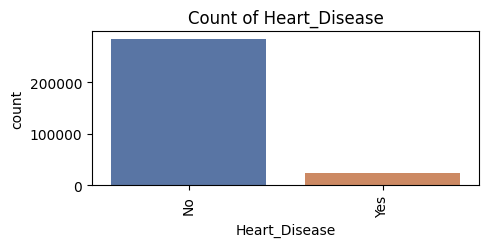

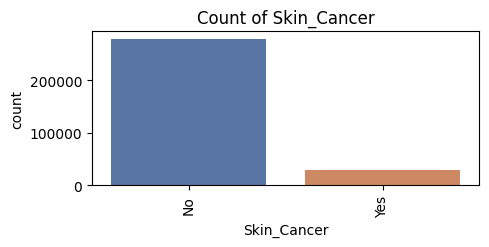

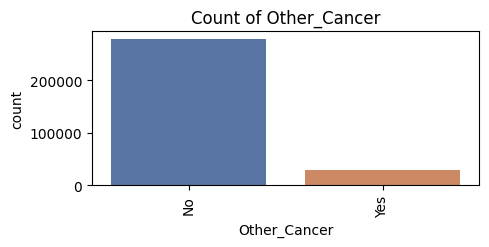

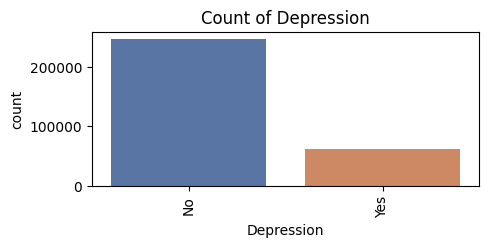

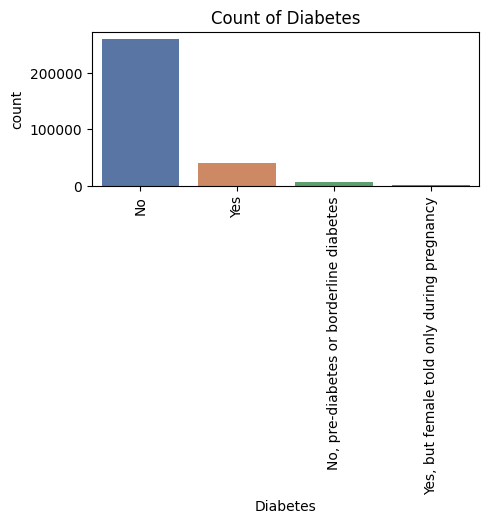

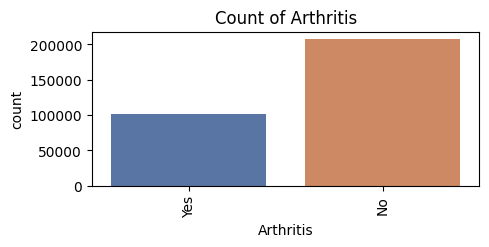

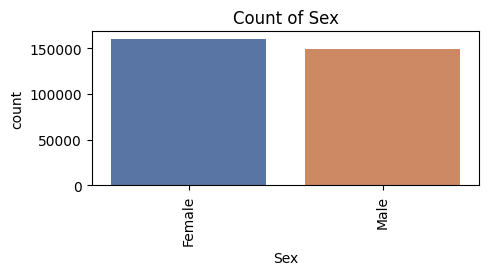

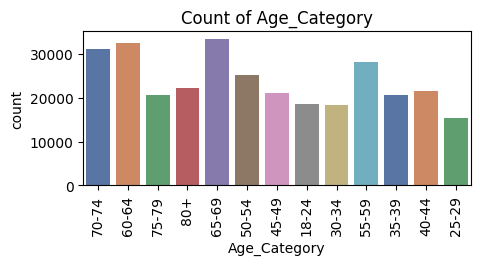

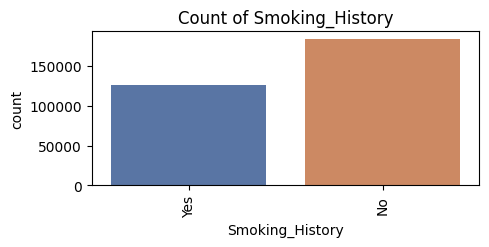

In [10]:
categorical_features = ['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']

for feature in categorical_features:
    plt.figure(figsize=(5, 2))
    sns.countplot(x=df[feature], palette='deep')
    plt.title('Count of ' + feature)
    plt.xticks(rotation=90)
    plt.show()

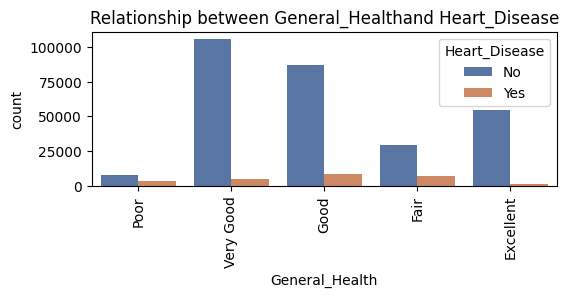

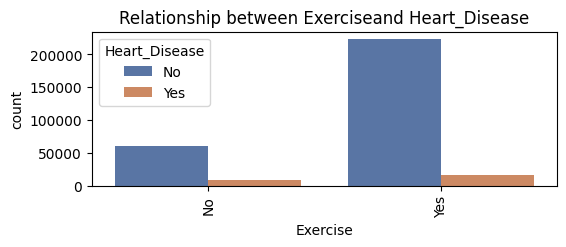

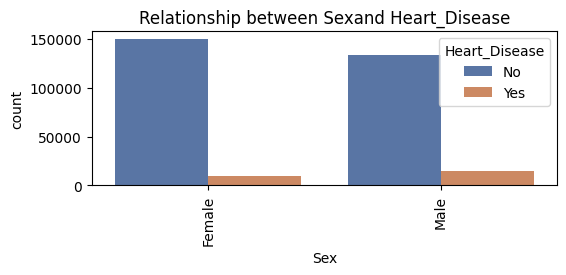

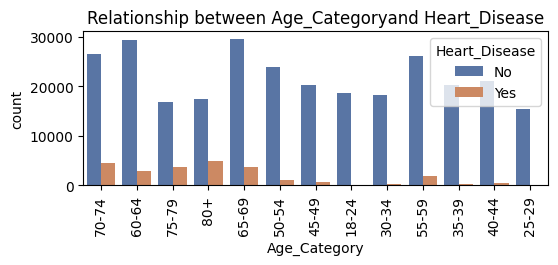

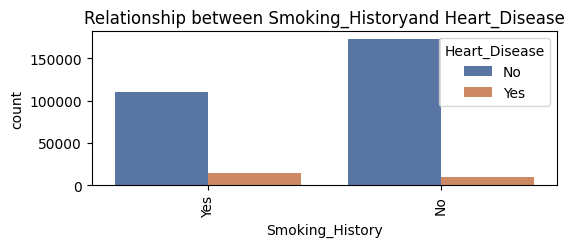

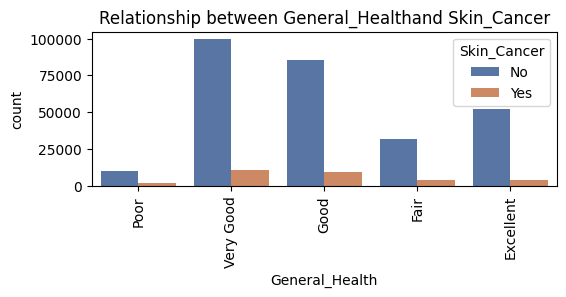

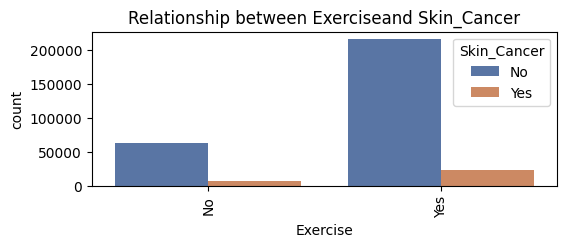

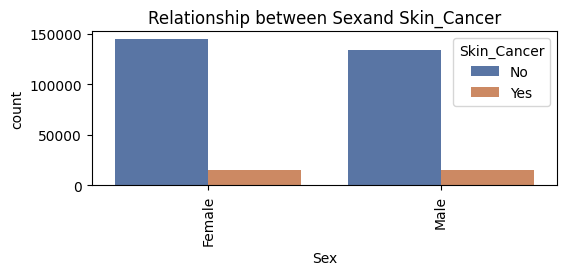

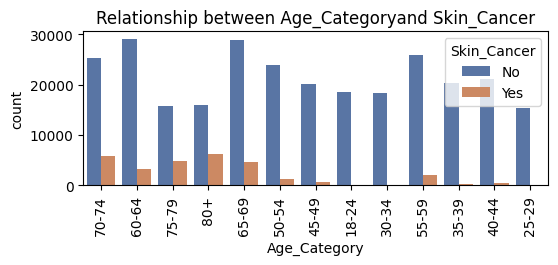

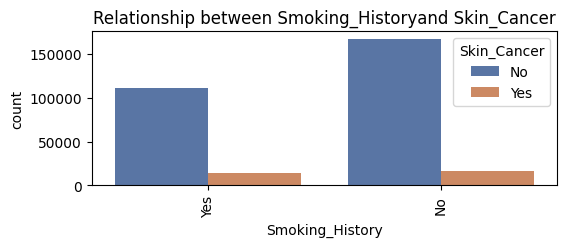

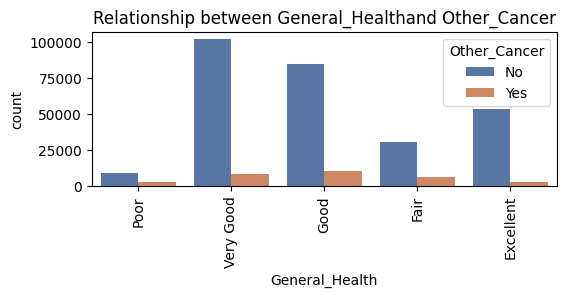

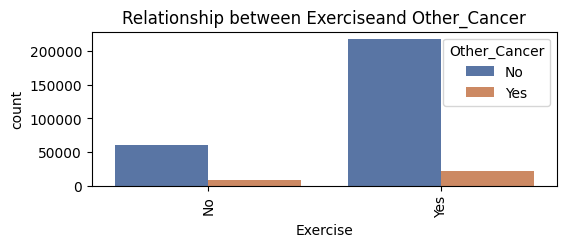

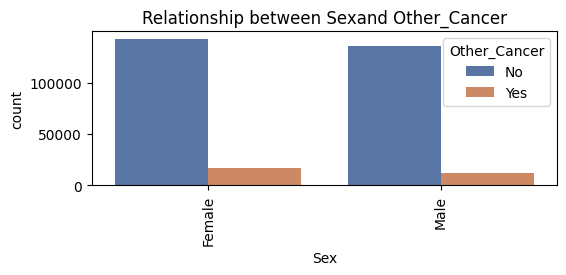

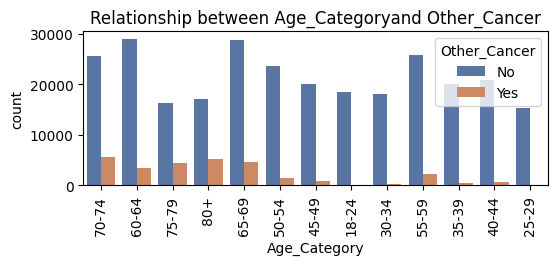

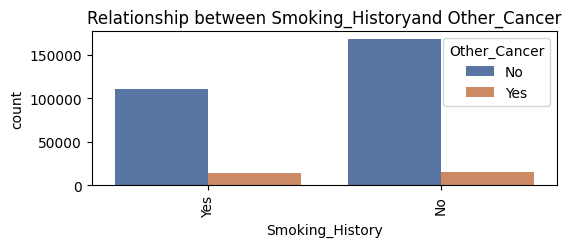

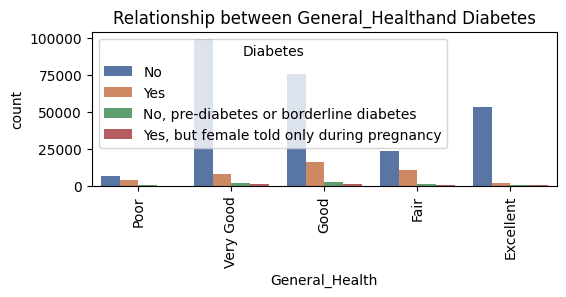

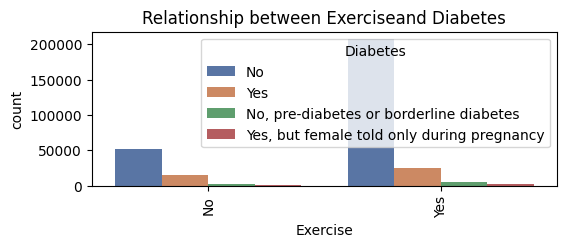

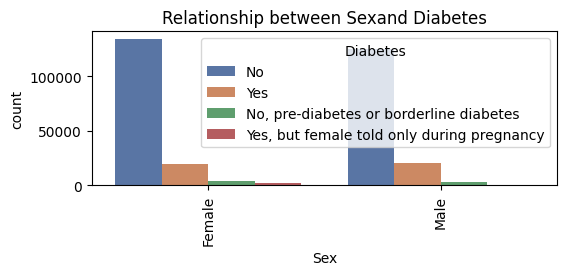

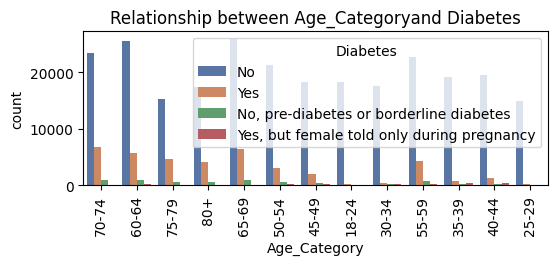

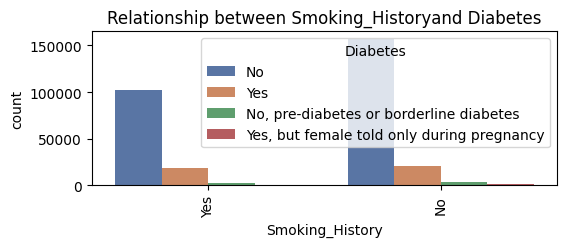

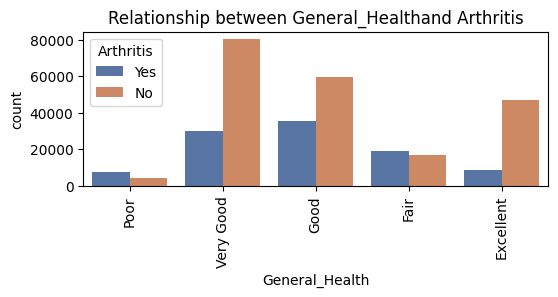

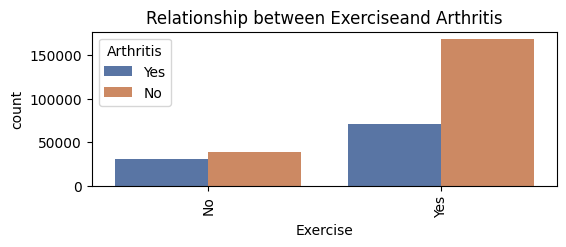

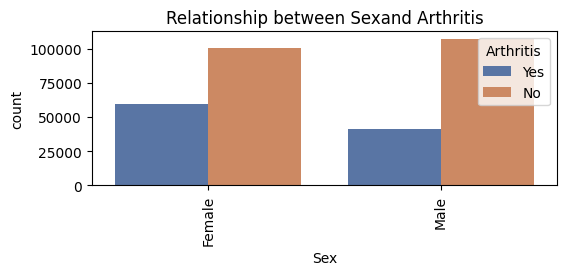

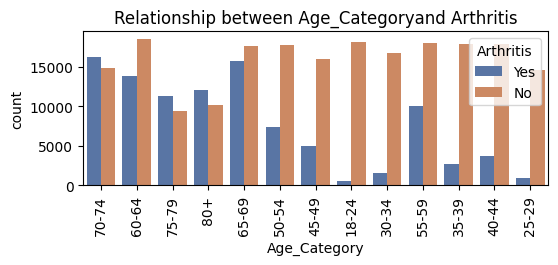

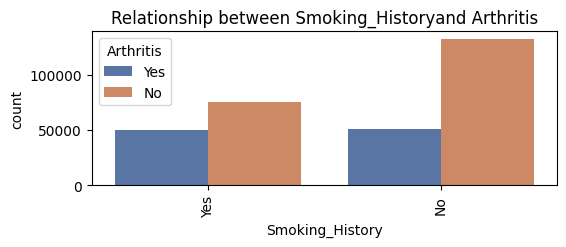

In [12]:
#We conducted a statistical analysis of the relationships between key diseases and behavioral variables.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

selected_variables = ['General_Health', 'Exercise', 'Sex', 'Age_Category', 'Smoking_History']
disease_conditions = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Diabetes', 'Arthritis']

for disease in disease_conditions:
  for variable in selected_variables:
    plt.figure(figsize=(6, 2))
    sns.countplot(data=df, x=variable, hue=disease, palette='deep' )
    plt.title('Relationship between ' + variable + 'and ' + disease)
    plt.xticks(rotation=90)
    plt.show()

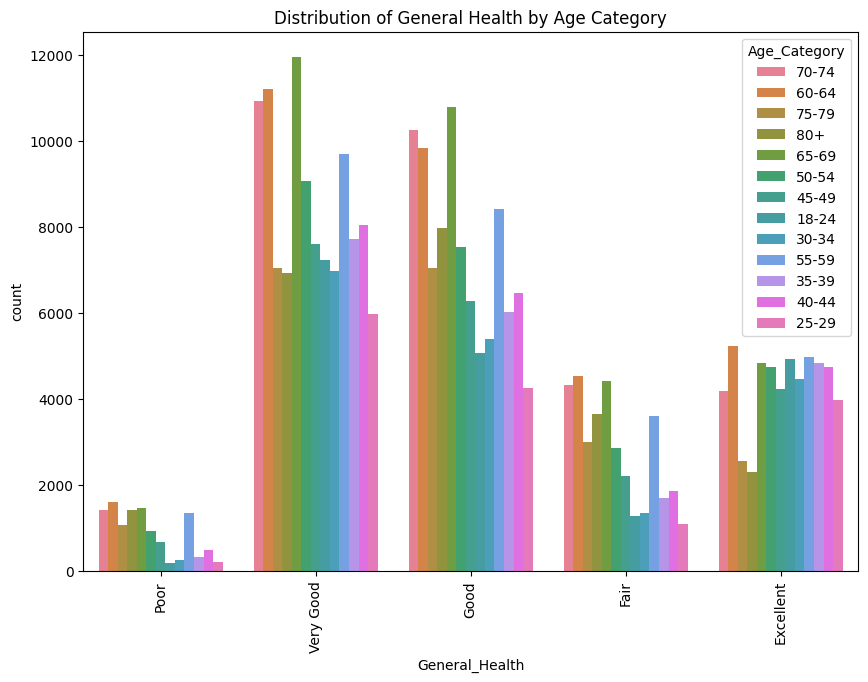

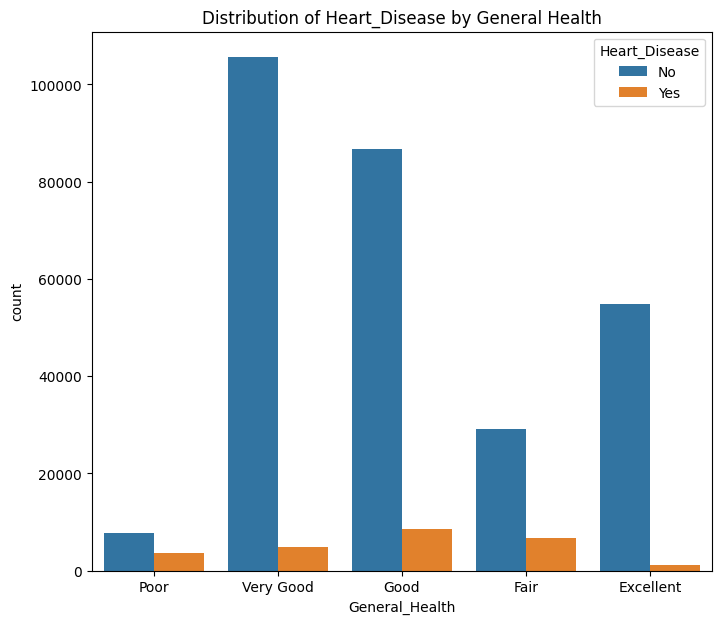

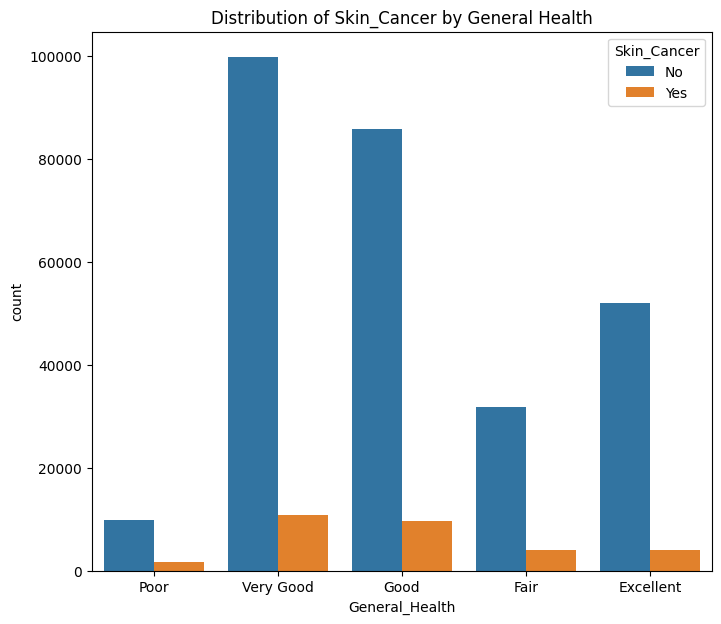

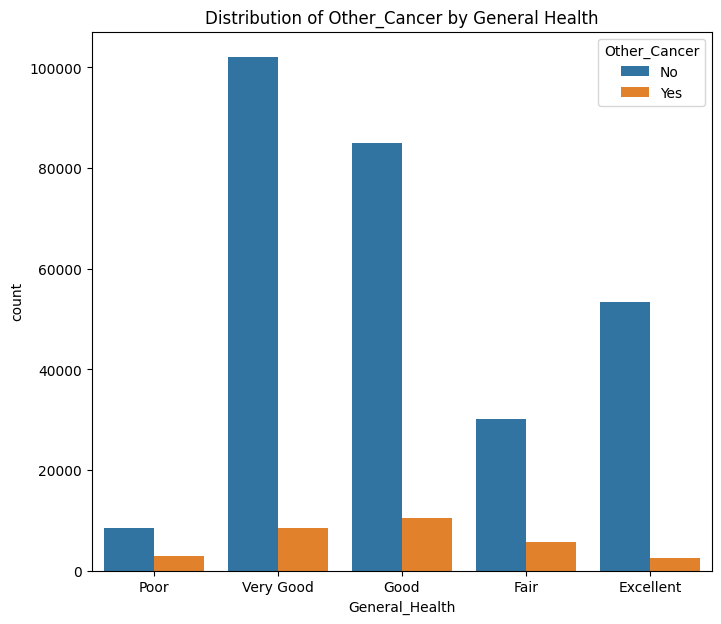

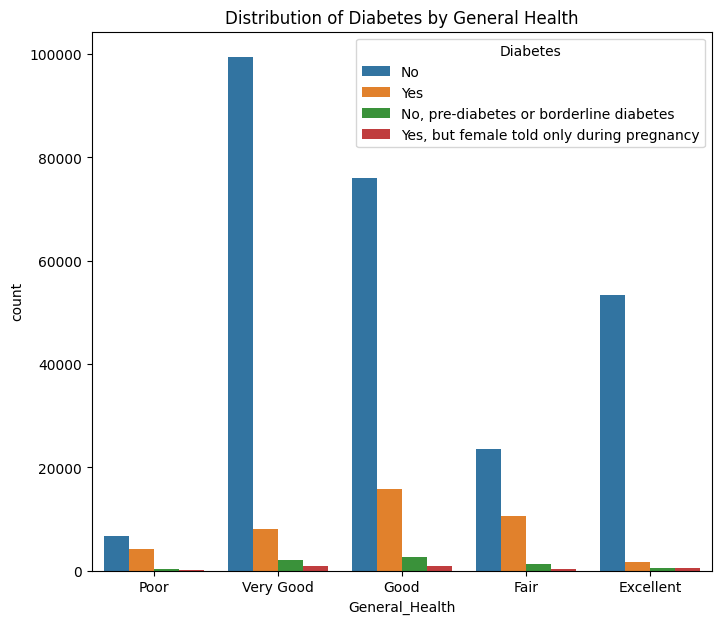

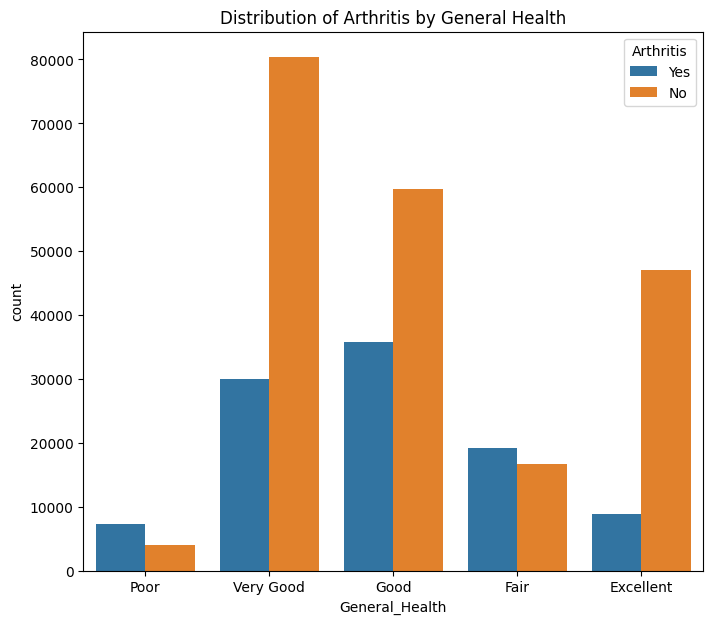

In [14]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='General_Health', hue='Age_Category')
plt.title('Distribution of General Health by Age Category')
plt.xticks(rotation=90)
plt.show()

for disease in disease_conditions:
  plt.figure(figsize=(8, 7))
  sns.countplot(data=df, x='General_Health',hue=disease)
  plt.title('Distribution of ' + disease + ' by General Health')
  plt.show()

DATA CLEANING

(General_Health                  0
 Checkup                         0
 Exercise                        0
 Heart_Disease                   0
 Skin_Cancer                     0
 Other_Cancer                    0
 Depression                      0
 Diabetes                        0
 Arthritis                       0
 Sex                             0
 Age_Category                    0
 Height_(cm)                     0
 Weight_(kg)                     0
 BMI                             0
 Smoking_History                 0
 Alcohol_Consumption             0
 Fruit_Consumption               0
 Green_Vegetables_Consumption    0
 FriedPotato_Consumption         0
 dtype: int64,
 <Axes: >)

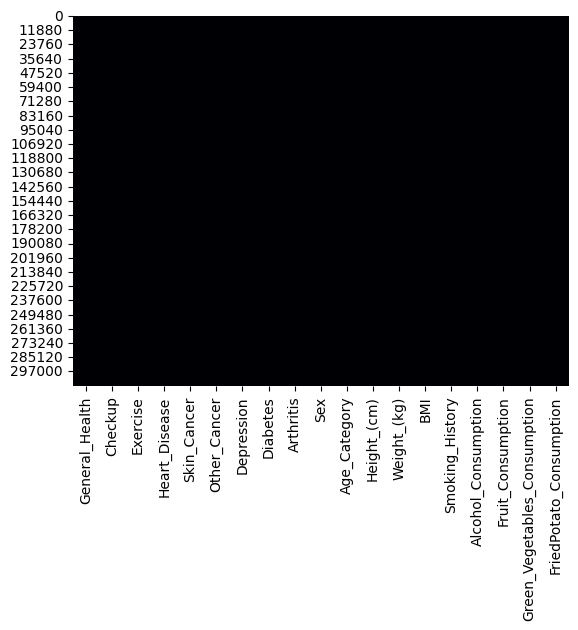

In [15]:
df.isna().sum(),sns.heatmap(df.isna(),cmap='magma', cbar=False)

In [16]:
df.duplicated().sum()

80

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df["Diabetes"].unique()

array(['No', 'Yes', 'No, pre-diabetes or borderline diabetes',
       'Yes, but female told only during pregnancy'], dtype=object)

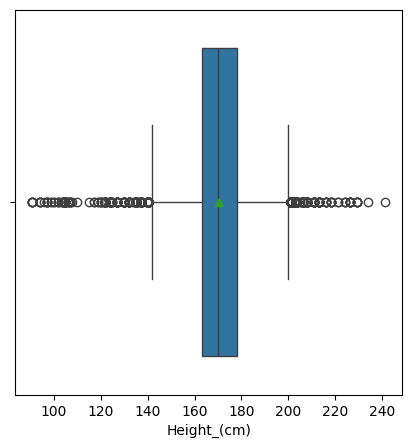

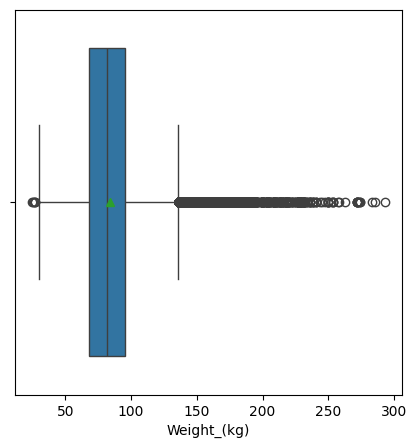

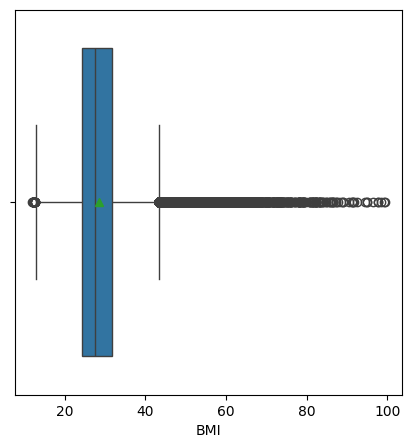

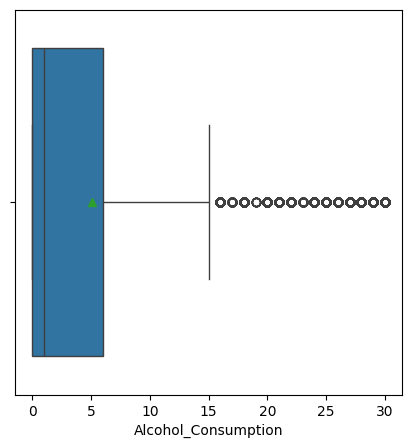

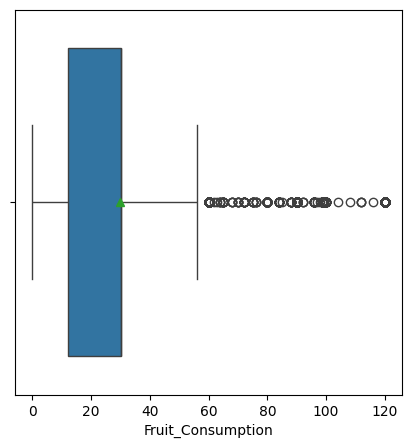

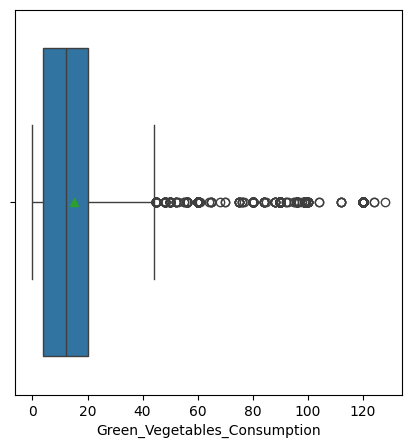

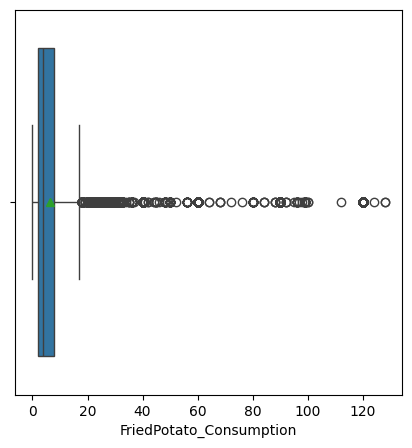

In [19]:
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  plt.figure(figsize=(5,5))
  sns.boxplot(x=i,data=df,showmeans=True)
  plt.show()


In [20]:
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  print("Minimium value of ",i,"is",df[i].min())
  print("Mean value of ",i,"is",df[i].mean())
  print("Maximum value of ",i,"is",df[i].max())
  print("-"*75)

Minimium value of  Height_(cm) is 91.0
Mean value of  Height_(cm) is 170.61522019341007
Maximum value of  Height_(cm) is 241.0
---------------------------------------------------------------------------
Minimium value of  Weight_(kg) is 24.95
Mean value of  Weight_(kg) is 83.59039922402795
Maximum value of  Weight_(kg) is 293.02
---------------------------------------------------------------------------
Minimium value of  BMI is 12.02
Mean value of  BMI is 28.626813235570356
Maximum value of  BMI is 99.33
---------------------------------------------------------------------------
Minimium value of  Alcohol_Consumption is 0.0
Mean value of  Alcohol_Consumption is 5.097556789107891
Maximum value of  Alcohol_Consumption is 30.0
---------------------------------------------------------------------------
Minimium value of  Fruit_Consumption is 0.0
Mean value of  Fruit_Consumption is 29.834289804193357
Maximum value of  Fruit_Consumption is 120.0
---------------------------------------------

In [21]:
 # Counting the ouliers in each feature
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  Q1 = df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1-3*IQR
  upper = Q3+3*IQR
  ot_cnt = ((df[i]<lower) | (df[i]>upper)).sum()
  ot_percentage = np.divide(np.multiply(ot_cnt,100),308854)
  ot_round = np.round(ot_percentage,decimals=0)
  print(i," : ",ot_cnt," : ",ot_round,"%")

Height_(cm)  :  82  :  0.0 %
Weight_(kg)  :  684  :  0.0 %
BMI  :  1279  :  0.0 %
Alcohol_Consumption  :  21221  :  7.0 %
Fruit_Consumption  :  19939  :  6.0 %
Green_Vegetables_Consumption  :  2889  :  1.0 %
FriedPotato_Consumption  :  11254  :  4.0 %


In [22]:
lst = [ 'Height_(cm)', 'Weight_(kg)', 'BMI','Alcohol_Consumption', 'Fruit_Consumption','Green_Vegetables_Consumption', 'FriedPotato_Consumption']
for i in lst:
  Q1 = df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1-3*IQR
  upper = Q3+3*IQR
  df= df[(df[i]>=lower) &(df[i]<=upper)|(df[i].isnull())]
df.reset_index(drop=True, inplace=True)
df.shape

(256262, 19)